In [ ]:
import os
import sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
from timm import create_model
from PIL import Image
from tqdm import tqdm
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import defaultdict

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from metrics.CKA import linear_CKA
from metrics.CKNNA import AlignmentMetrics

Please install the pymp library using `pip install pymp` to speed up non-batched metrics


In this task, we focus on evaluating the representational quality of different layers in a pretrained Vision Transformer model, specifically the DINO self-supervised model. We extract features from each transformer block and train lightweight linear classifiers (linear probes). This procedure allows us to measure how linearly separable the learned features are at each depth of the network. The primary goal is to understand which layers encode the most useful semantic information for classification tasks. This analysis serves as a foundation for subsequent investigations, such as layer-skipping strategies or representational redundancy detection, aiming to optimize inference without significantly sacrificing model performance.

In [2]:
def extract_layer_outputs(model, x):
    '''
    Extracts intermediate layer outputs from a ViT model during a forward pass.
    '''
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    hooks = [blk.register_forward_hook(hook_fn) for blk in model.blocks]

    with torch.no_grad():
        _ = model(x)

    for hook in hooks:
        hook.remove()

    return activations


def compute_logits_from_layers(model, layer_outputs):
    '''
    Computes classification logits from intermediate layer representations using the model's head.
    '''
    cls_tokens = [output[:, 0] for output in layer_outputs]  # CLS token
    norm = model.norm
    head = model.head
    logits = [head(norm(cls)) for cls in cls_tokens]
    return logits


def collect_logits_from_batches(model, dataloader, max_batches=None):
    '''
    Collects logits from all transformer layers for multiple batches of data.
    '''
    all_logits = []

    for batch_idx, (x_batch, _) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_batch = x_batch.to(next(model.parameters()).device)
        layer_outputs = extract_layer_outputs(model, x_batch)
        logits = compute_logits_from_layers(model, layer_outputs)
        all_logits.append(logits)

    return all_logits

In [ ]:
def compute_cka_matrix(logits):
    L = len(logits)
    matrix = torch.zeros(L, L)
    logits = [F.normalize(logit.detach(), dim=-1) for logit in logits]

    for i in range(L):
        for j in range(i, L):
            val = linear_CKA(logits[i], logits[j])
            matrix[i, j] = val
            matrix[j, i] = val

    return matrix.numpy()


def compute_cosine_similarity_matrix(logits):
    """
    Fully vectorized computation of cosine similarity matrix between L layer outputs.
    Uses F.cosine_similarity and removes nested loops.
    """
    x = torch.stack([F.normalize(t.detach(), dim=-1) for t in logits])

    x1 = x[:, None, :, :] 
    x2 = x[None, :, :, :]

    cos = F.cosine_similarity(x1, x2, dim=-1)

    sim_matrix = cos.mean(dim=-1)

    return sim_matrix.cpu().numpy()


def compute_cknna_matrix(logits, k=10):
    L = len(logits)
    matrix = np.zeros((L, L))
    
    for i in range(L):
        for j in range(i, L):
            sim = AlignmentMetrics.cknna(logits[i], logits[j], topk=k)
            matrix[i, j] = sim
            matrix[j, i] = sim
    
    return matrix

In [4]:
def plot_skip_layer_accuracy(results, similarity_matrix, title, full_model_accuracy):
    """
    Plots accuracy vs skipping a single layer, coloring bars by CKA similarity between this layers.
    """
    single_skip_results = [res for res in results if len(res['skipped_layers']) == 1]

    cka_similarities = [
        similarity_matrix[i, i+1] if i < len(similarity_matrix) - 1 else similarity_matrix[i-1, i]
        for i in range(len(similarity_matrix))
    ]

    norm = plt.Normalize(min(cka_similarities), max(cka_similarities))
    colors = cm.viridis(norm(cka_similarities))

    x = [res['skipped_layers'][0] for res in single_skip_results]
    y = [res['accuracy'] for res in single_skip_results]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(x, y, color=colors)
    plt.axhline(y=full_model_accuracy, color='r', linestyle='--')
    plt.xlabel("Skipped layer")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def plot_double_skip_accuracy(results, similarity_matrix, title, full_model_accuracy):
    """
    Plots accuracy vs skipping two consecutive layers, coloring bars by CKA similarity between those layers.
    """
    double_skip_results = [
        res for res in results
        if len(res['skipped_layers']) == 2 and res['skipped_layers'][1] - res['skipped_layers'][0] == 1
    ]

    cka_similarities = []
    for res in double_skip_results:
        i = res['skipped_layers'][0]
        if i + 2 < similarity_matrix.shape[0]:
            cka_similarities.append(similarity_matrix[i, i+2])
        else:
            cka_similarities.append(similarity_matrix[i-1, i])


    norm = plt.Normalize(min(cka_similarities), max(cka_similarities))
    colors = cm.viridis(norm(cka_similarities))

    x_labels = [f"{i}-{j}" for i, j in [res['skipped_layers'] for res in double_skip_results]]
    x_pos = np.arange(len(x_labels))
    accuracies = [res['accuracy'] for res in double_skip_results]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(x_pos, accuracies, color=colors)
    plt.axhline(y=full_model_accuracy, color='r', linestyle='--')
    plt.xticks(x_pos, x_labels)
    plt.xlabel("Skipped layers")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:
SELECTED_CLASSES = ['n01632777', 'n01984695', 'n01728572', 'n01514859',
                    'n01614925', 'n01582220', 'n01806143', 'n01819313']


class SelectedImageNet(Dataset):
    def __init__(self, root_dirs, selected_classes, transform=None):
        self.root_dirs = [root_dirs] if isinstance(root_dirs, str) else root_dirs
        self.selected_classes = selected_classes
        self.transform = transform
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(list(self.selected_classes)))}
        self.samples = self._find_samples()

    def _find_samples(self):
        samples = []
        for root_dir in self.root_dirs:
            if not os.path.isdir(root_dir):
                print(f"Warning: Directory not found {root_dir}, skipping.")
                continue
            for class_name in os.listdir(root_dir):
                if class_name in self.selected_classes:
                    class_path = os.path.join(root_dir, class_name)
                    if os.path.isdir(class_path):
                        for img_name in os.listdir(class_path):
                            img_path = os.path.join(class_path, img_name)
                            if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                                samples.append((img_path, self.class_to_idx[class_name]))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


base_train_dir = "..\\data"
train_dirs = [os.path.join(base_train_dir, f"train.X{i}") for i in range(1, 5)]
val_path = os.path.join(base_train_dir, "val.X")

train_dataset = SelectedImageNet(train_dirs, SELECTED_CLASSES, transform=train_transform)


val_dataset = SelectedImageNet(val_path, SELECTED_CLASSES, transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [7]:
@torch.no_grad()
def forward_with_skipping(model, x, skip_layers=[]):
    x = model.patch_embed(x)
    cls_token = model.cls_token.expand(x.shape[0], -1, -1)
    x = torch.cat((cls_token, x), dim=1)
    x = x + model.pos_embed
    x = model.pos_drop(x)

    for i, blk in enumerate(model.blocks):
        if i in skip_layers:
            continue
        x = blk(x)

    x = model.norm(x)
    cls_token_out = x[:, 0]
    return cls_token_out

@torch.no_grad()
def collect_outputs_with_skipping(model, dataloader, skip_layers=[], max_batches=None):
    outputs = []
    all_labels = []
    for i, (images, labels) in enumerate(tqdm(dataloader, desc="Collecting outputs")):
        if max_batches and i >= max_batches:
            break
        images = images.to(device)
        cls_token_out = forward_with_skipping(model, images, skip_layers)
        outputs.append(cls_token_out.cpu())
        all_labels.extend(labels.numpy())

    return torch.cat(outputs).numpy(), np.array(all_labels)

In [8]:
def evaluate_full_model(model, dataloader, linear_classifier, max_layer=12, max_batches=None):
    results = []

    print("\n[INFO] Evaluating full model...\n")
    
    skipped = []
    X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skipped, max_batches=max_batches)

    inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = linear_classifier(inputs)
        y_pred = outputs.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

    print(f"→ Accuracy: {acc:.4f}")

    results.append({
        'skipped_layers': skipped,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })

    print(results)

In [9]:
def evaluate_skipped_layers(model, dataloader, linear_classifier, max_layer=12, max_batches=None):
    results = []

    print("\n[INFO] Evaluating individual skipped layers...\n")
    for i in range(max_layer):
        skipped = [i]
        print(f"\n[INFO] Skipping layer: {skipped}")
        X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skipped, max_batches=max_batches)

        inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
        with torch.no_grad():
            outputs = linear_classifier(inputs)
            y_pred = outputs.argmax(dim=1).cpu().numpy()

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

        print(f"→ Accuracy: {acc:.4f}")

        results.append({
            'skipped_layers': skipped,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1
        })

    print("\n[INFO] Evaluating pairs of consecutive skipped layers...\n")
    for i in range(max_layer - 1):
        skipped = [i, i + 1]
        print(f"\n[INFO] Skipping layers: {skipped}")
        X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skipped, max_batches=max_batches)

        inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
        with torch.no_grad():
            outputs = linear_classifier(inputs)
            y_pred = outputs.argmax(dim=1).cpu().numpy()

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

        results.append({
            'skipped_layers': skipped,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1
        })

    return results

#### Model DINO ViT-S/16

In [10]:
class LinearClassifier(nn.Module):
    """Linear layer to train on top of frozen features"""
    def __init__(self, dim, num_labels=1000):
        super(LinearClassifier, self).__init__()
        self.num_labels = num_labels
        self.linear = nn.Linear(dim, num_labels)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_dim = 384 
num_labels = 8 

linear_classifier = LinearClassifier(dim=embed_dim, num_labels=num_labels)
linear_classifier.to(device)

checkpoint = torch.load("../linear_probe/best_model_dino_S16.pth", map_location=device)
linear_classifier.load_state_dict(checkpoint['model'])
linear_classifier.eval()

model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


Using cache found in C:\Users\okroj/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [11]:
evaluate_full_model(model, val_loader, linear_classifier)


[INFO] Evaluating full model...



→ Accuracy: 0.9850
[{'skipped_layers': [], 'accuracy': 0.985, 'precision': 0.9853393665158372, 'recall': 0.985, 'f1_score': 0.9849714812417616}]


In [14]:
results = evaluate_skipped_layers(model, val_loader, linear_classifier)
results


[INFO] Evaluating individual skipped layers...


[INFO] Skipping layer: [0]


→ Accuracy: 0.1125

[INFO] Skipping layer: [1]


→ Accuracy: 0.9675

[INFO] Skipping layer: [2]


→ Accuracy: 0.9725

[INFO] Skipping layer: [3]


→ Accuracy: 0.9750

[INFO] Skipping layer: [4]


...


[INFO] Skipping layers: [7, 8]



[INFO] Skipping layers: [8, 9]



[INFO] Skipping layers: [9, 10]



[INFO] Skipping layers: [10, 11]


[{'skipped_layers': [0],
  'accuracy': 0.1125,
  'precision': 0.014841688654353561,
  'recall': 0.1125,
  'f1_score': 0.026223776223776224},
 {'skipped_layers': [1],
  'accuracy': 0.9675,
  'precision': 0.9684741802703988,
  'recall': 0.9675,
  'f1_score': 0.9675055059238955},
 {'skipped_layers': [2],
  'accuracy': 0.9725,
  'precision': 0.9730126693275278,
  'recall': 0.9724999999999999,
  'f1_score': 0.972492555421698},
 {'skipped_layers': [3],
  'accuracy': 0.975,
  'precision': 0.9756638548017176,
  'recall': 0.975,
  'f1_score': 0.9750428257548537},
 {'skipped_layers': [4],
  'accuracy': 0.98,
  'precision': 0.9806148351938744,
  'recall': 0.98,
  'f1_score': 0.9800180732796062},
 {'skipped_layers': [5],
  'accuracy': 0.9775,
  'precision': 0.9781710761227568,
  'recall': 0.9775,
  'f1_score': 0.9775175146566277},
 {'skipped_layers': [6],
  'accuracy': 0.97,
  'precision': 0.9708994105624833,
  'recall': 0.97,
  'f1_score': 0.9700625443669794},
 {'skipped_layers': [7],
  'accuracy

In [12]:
model.eval()

all_logits = collect_logits_from_batches(model, dataloader=train_loader, max_batches=20)

num_layers = len(all_logits[0])
combined_logits = []

for layer_idx in range(num_layers):
    layer_logits = [batch[layer_idx] for batch in all_logits]
    combined = torch.cat(layer_logits, dim=0)
    combined_logits.append(combined)

cka_matrix = compute_cka_matrix(combined_logits)
cos_matrix = compute_cosine_similarity_matrix(combined_logits)
cknna_matrix = compute_cknna_matrix(combined_logits)


C:\Users\okroj\AppData\Local\Temp\ipykernel_14536\2153841135.py:24: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


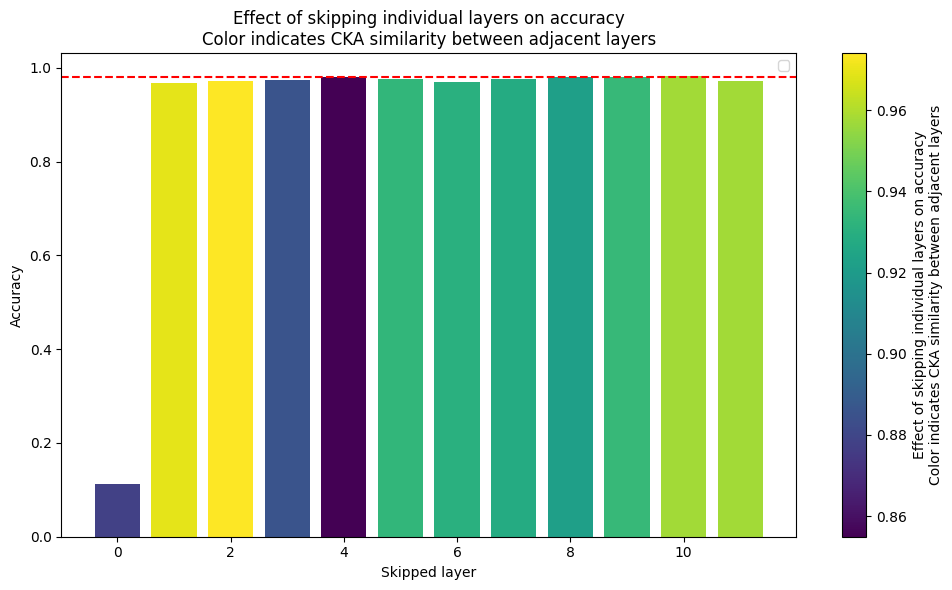

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


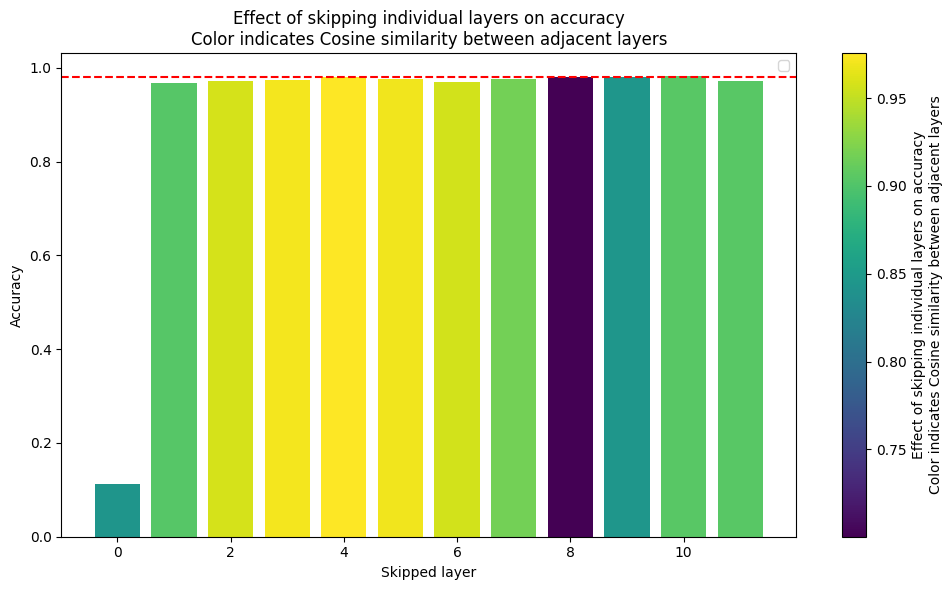

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


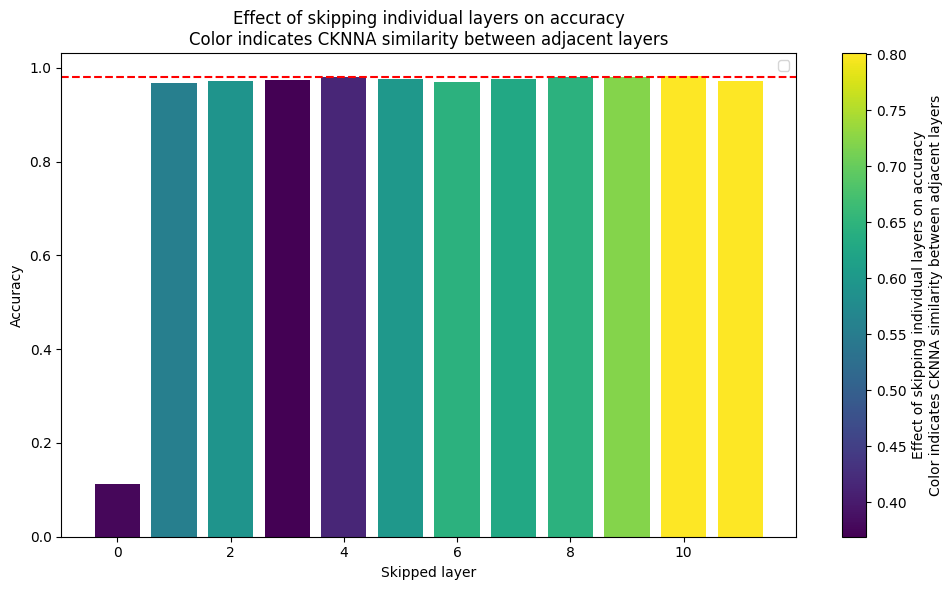

In [ ]:
plot_skip_layer_accuracy(
    results,
    cka_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates CKA similarity between adjacent layers", 0.98
)

plot_skip_layer_accuracy(
    results,
    cos_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates Cosine similarity between adjacent layers", 0.98
)

plot_skip_layer_accuracy(
    results,
    cknna_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates CKNNA similarity between adjacent layers", 0.98
)


C:\Users\okroj\AppData\Local\Temp\ipykernel_14536\3938781216.py:33: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


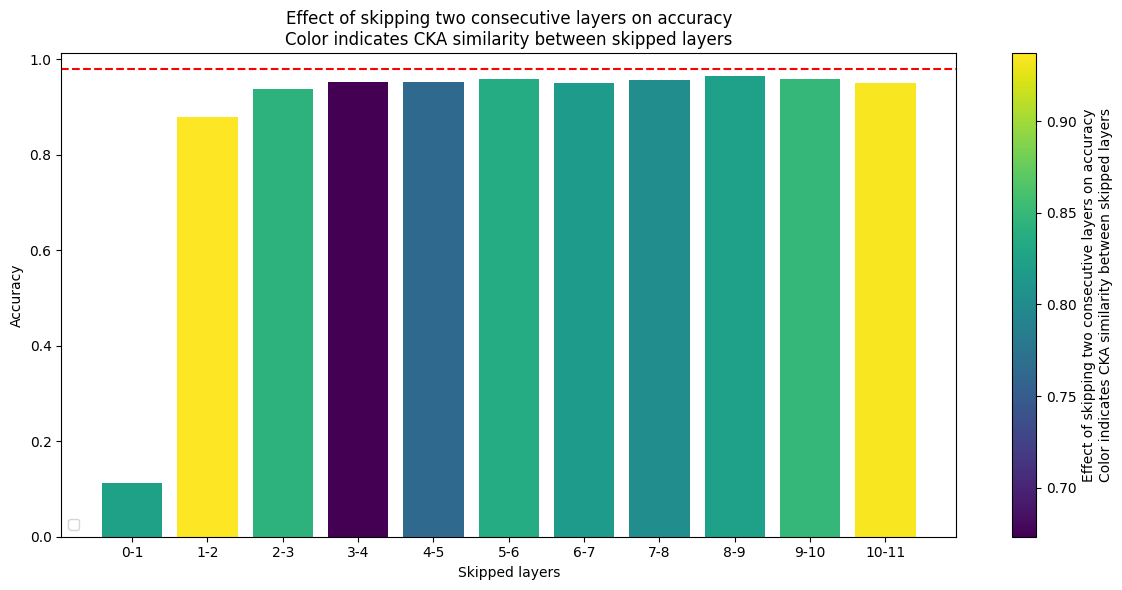

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


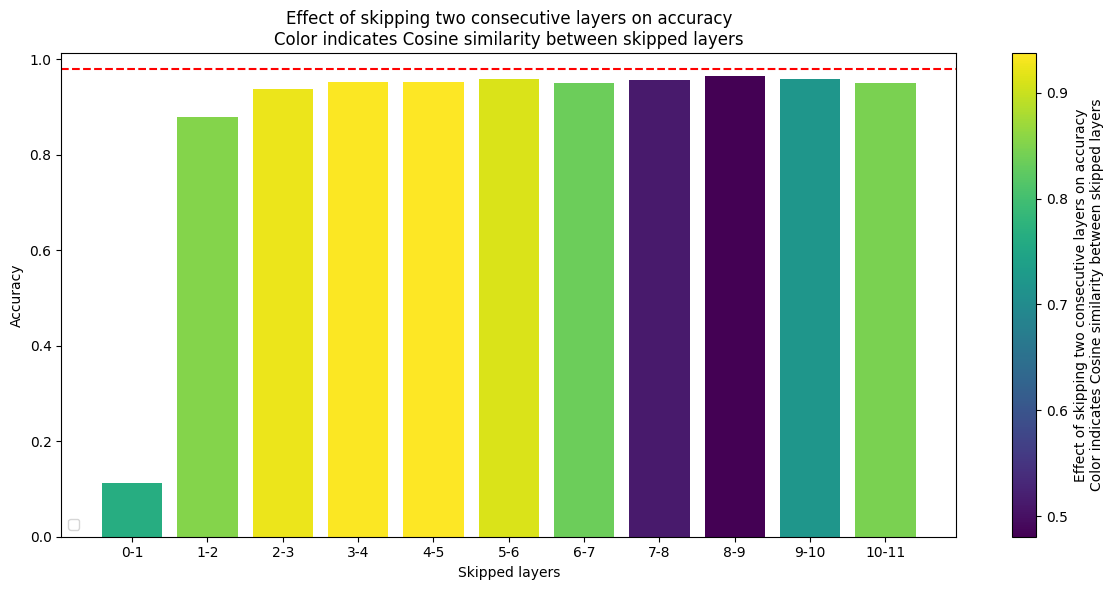

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


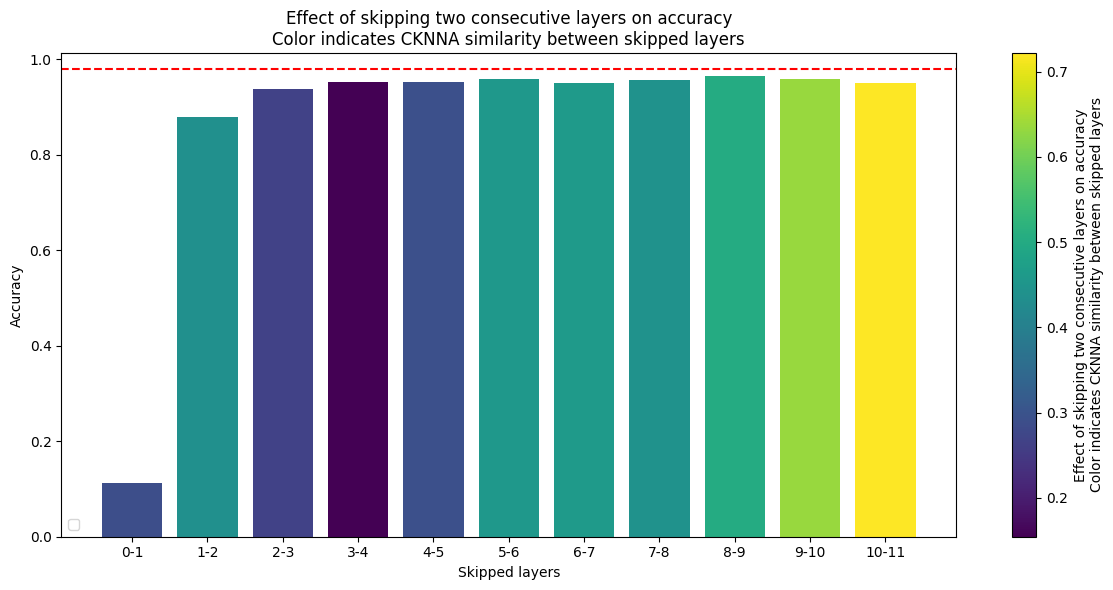

In [17]:
plot_double_skip_accuracy(
    results,
    cka_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates CKA similarity between skipped layers", 0.98
)

plot_double_skip_accuracy(
    results,
    cos_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates Cosine similarity between skipped layers", 0.98
)

plot_double_skip_accuracy(
    results,
    cknna_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates CKNNA similarity between skipped layers", 0.98
)


#### Model DINO ViT-B/8

In [ ]:
class LinearClassifier(nn.Module):
    """Linear layer to train on top of frozen features"""
    def __init__(self, dim, num_labels=1000):
        super(LinearClassifier, self).__init__()
        self.num_labels = num_labels
        self.linear = nn.Linear(dim, num_labels)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embed_dim = 768 
num_labels = 8 

linear_classifier = LinearClassifier(dim=embed_dim, num_labels=num_labels)
linear_classifier.to(device)

checkpoint = torch.load("../linear_probe/best_model_dino_B8.pth", map_location=device)
linear_classifier.load_state_dict(checkpoint['model'])
linear_classifier.eval()

model = torch.hub.load('facebookresearch/dino:main', 'dino_vitb8')
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Using cache found in C:\Users\okroj/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [14]:
evaluate_full_model(model, val_loader, linear_classifier)


[INFO] Evaluating full model...



→ Accuracy: 0.9875
[{'skipped_layers': [], 'accuracy': 0.9875, 'precision': 0.9875960384153661, 'recall': 0.9875, 'f1_score': 0.98747399739974}]


In [ ]:
results = evaluate_skipped_layers(model, val_loader, linear_classifier)
results


[INFO] Evaluating individual skipped layers...


[INFO] Skipping layer: [0]


→ Accuracy: 0.1075

[INFO] Skipping layer: [1]


→ Accuracy: 0.9700

[INFO] Skipping layer: [2]


→ Accuracy: 0.9825

[INFO] Skipping layer: [3]


→ Accuracy: 0.9800

[INFO] Skipping layer: [4]


...


[INFO] Skipping layers: [7, 8]



[INFO] Skipping layers: [8, 9]



[INFO] Skipping layers: [9, 10]



[INFO] Skipping layers: [10, 11]


[{'skipped_layers': [0],
  'accuracy': 0.1075,
  'precision': 0.11048656000861883,
  'recall': 0.10750000000000001,
  'f1_score': 0.09056863019113967},
 {'skipped_layers': [1],
  'accuracy': 0.97,
  'precision': 0.9705774254146102,
  'recall': 0.97,
  'f1_score': 0.969961973434392},
 {'skipped_layers': [2],
  'accuracy': 0.9825,
  'precision': 0.9826903068919876,
  'recall': 0.9824999999999999,
  'f1_score': 0.9824982645323356},
 {'skipped_layers': [3],
  'accuracy': 0.98,
  'precision': 0.9802883461076739,
  'recall': 0.98,
  'f1_score': 0.9799969990996698},
 {'skipped_layers': [4],
  'accuracy': 0.98,
  'precision': 0.9801450580232092,
  'recall': 0.98,
  'f1_score': 0.9799987498749875},
 {'skipped_layers': [5],
  'accuracy': 0.985,
  'precision': 0.9851883060916674,
  'recall': 0.985,
  'f1_score': 0.9849727619820806},
 {'skipped_layers': [6],
  'accuracy': 0.98,
  'precision': 0.9802373256995105,
  'recall': 0.98,
  'f1_score': 0.9799975144573281},
 {'skipped_layers': [7],
  'accur

In [ ]:
model.eval()

all_logits = collect_logits_from_batches(model, dataloader=train_loader, max_batches=20)

num_layers = len(all_logits[0])
combined_logits = []

for layer_idx in range(num_layers):
    layer_logits = [batch[layer_idx] for batch in all_logits]
    combined = torch.cat(layer_logits, dim=0)
    combined_logits.append(combined)

cka_matrix = compute_cka_matrix(combined_logits)
cos_matrix = compute_cosine_similarity_matrix(combined_logits)
cknna_matrix = compute_cknna_matrix(combined_logits)

C:\Users\okroj\AppData\Local\Temp\ipykernel_32616\2153841135.py:24: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


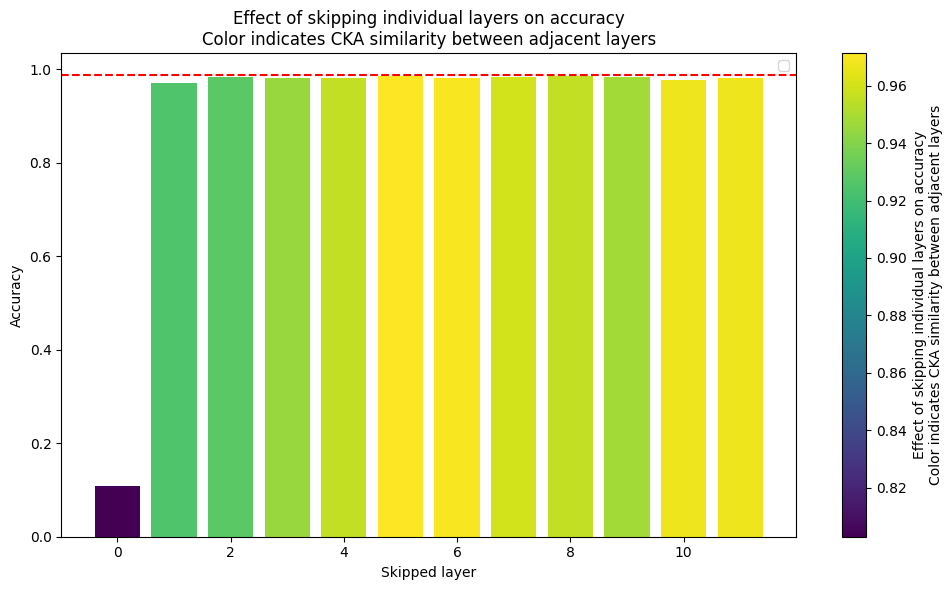

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


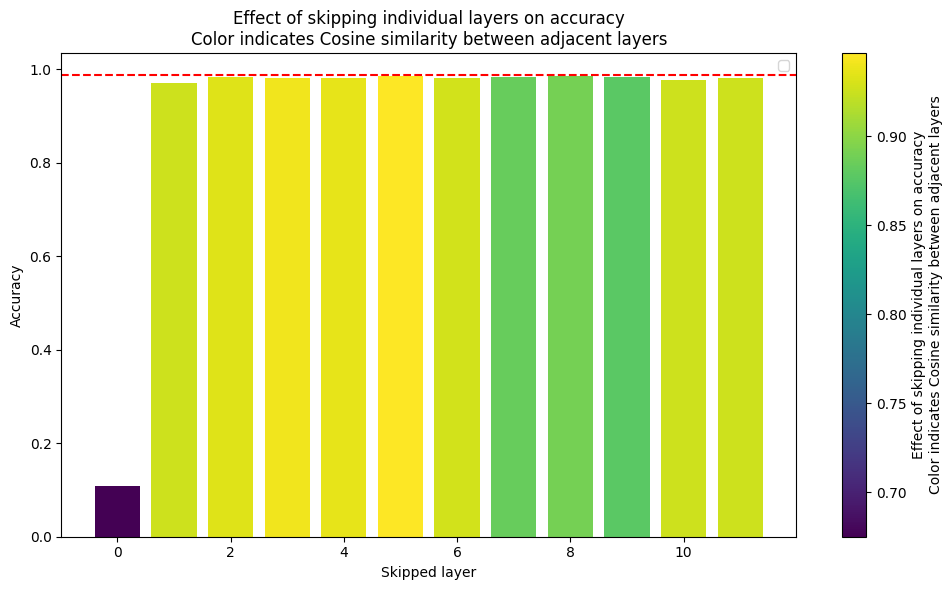

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


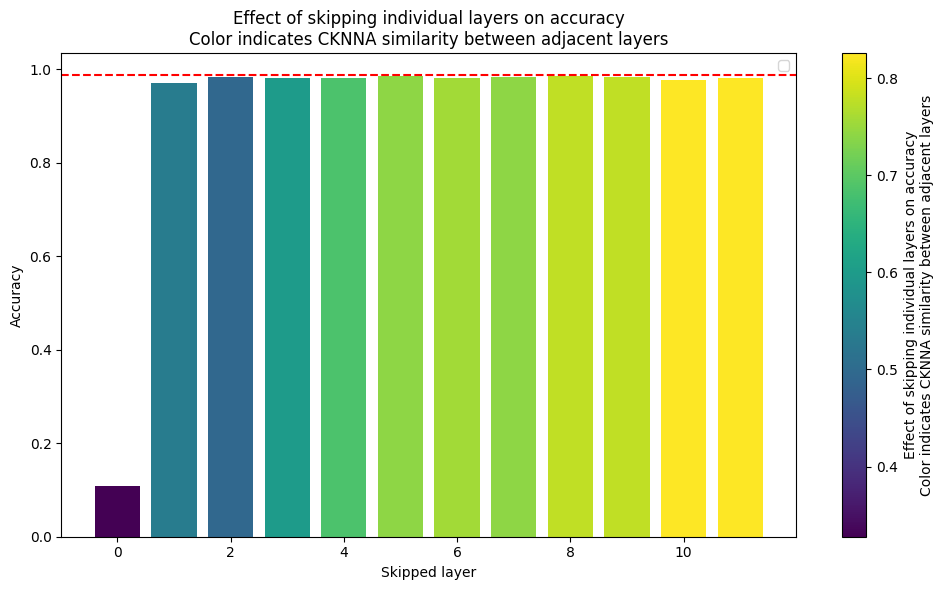

In [21]:
plot_skip_layer_accuracy(
    results,
    cka_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates CKA similarity between adjacent layers", 0.9875
)

plot_skip_layer_accuracy(
    results,
    cos_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates Cosine similarity between adjacent layers", 0.9875
)

plot_skip_layer_accuracy(
    results,
    cknna_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates CKNNA similarity between adjacent layers", 0.9875
)


C:\Users\okroj\AppData\Local\Temp\ipykernel_32616\3938781216.py:33: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


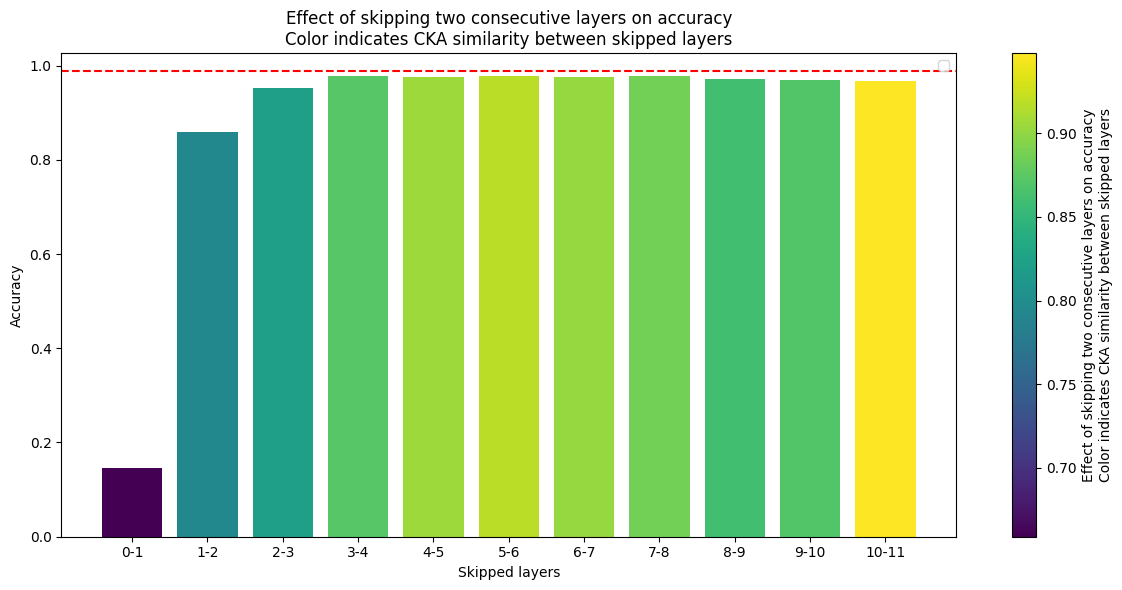

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


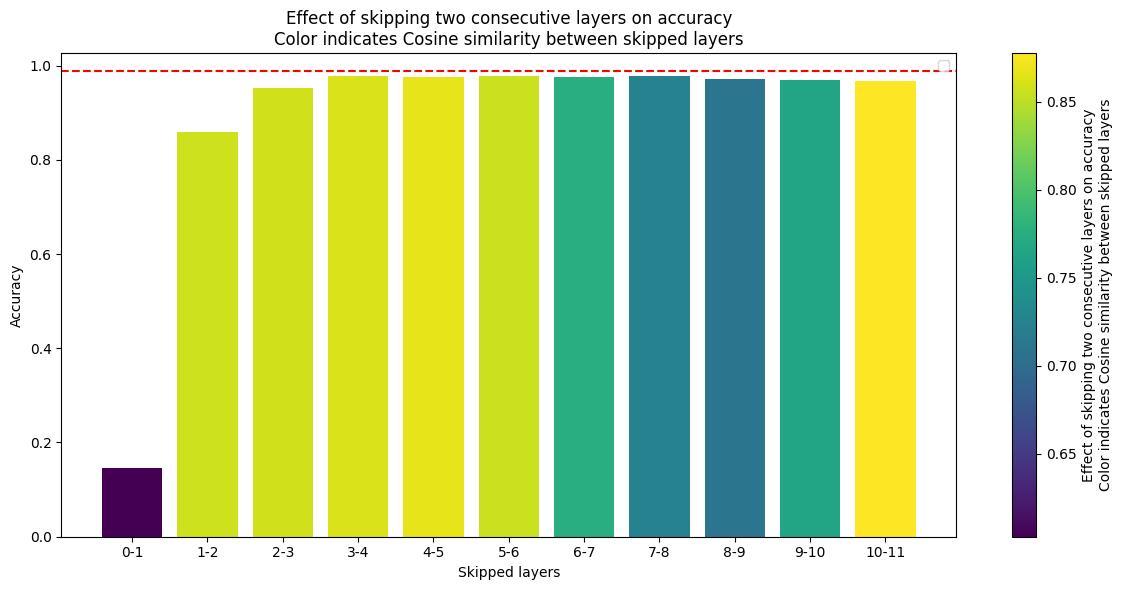

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


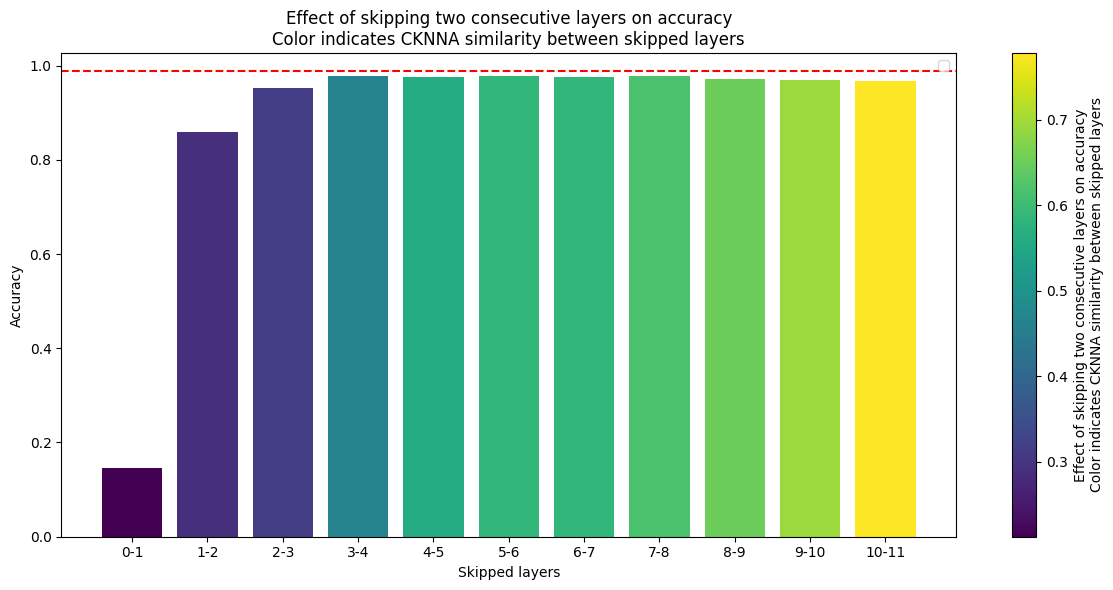

In [22]:
plot_double_skip_accuracy(
    results,
    cka_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates CKA similarity between skipped layers", 0.9875
)

plot_double_skip_accuracy(
    results,
    cos_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates Cosine similarity between skipped layers", 0.9875
)

plot_double_skip_accuracy(
    results,
    cknna_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates CKNNA similarity between skipped layers", 0.9875
)
